<a href="https://colab.research.google.com/github/Saideshmukh717/movie-project-for-microsoft/blob/main/04_popularity_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import pickle
# ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Warnings
import warnings
warnings.filterwarnings("ignore")

Import Libraries

In [2]:
movies = pd.read_csv('/tmdb_5000_movies.csv')

movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [3]:
df = movies[['title','genres','popularity','vote_count','vote_average']].copy()

In [4]:
import ast

def convert(text):
    L = []
    try:
        for i in ast.literal_eval(text):
            L.append(i['name'])
    except:
        return []
    return L

df['genres'] = df['genres'].apply(convert)

df.dropna(inplace=True)

Clean and Convert Generes

In [5]:
threshold = df['popularity'].median()

df['popular'] = df['popularity'].apply(lambda x: 1 if x >= threshold else 0)

df['popular'].value_counts()

,count
popular,
1,2402
0,2401


now we will fo feature engineering

In [6]:
df_exploded = df.explode('genres')

expand generes

In [7]:
df_encoded = pd.get_dummies(df_exploded, columns=['genres'])

one hot encoding

In [8]:
df_final = df_encoded.groupby(df_encoded.index).sum()

df_final.head()

,title,popularity,vote_count,vote_average,popular,genres_Action,genres_Adventure,genres_Animation,genres_Comedy,genres_Crime,...,genres_History,genres_Horror,genres_Music,genres_Mystery,genres_Romance,genres_Science Fiction,genres_TV Movie,genres_Thriller,genres_War,genres_Western
0,AvatarAvatarAvatarAvatar,601.750308,47200,28.8,4,1,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,Pirates of the Caribbean: At World's EndPirate...,417.247845,13500,20.7,3,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,SpectreSpectreSpectre,322.130364,13398,18.9,3,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,The Dark Knight RisesThe Dark Knight RisesThe ...,449.251800,36424,30.4,4,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,John CarterJohn CarterJohn Carter,131.780985,6372,18.3,3,1,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


aggreate back

In [15]:
X = df_final.drop(['popular', 'title'], axis=1)
y = df_final['popular']

prepare features & labels

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train and test

In [17]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       474
           1       1.00      0.99      0.99        68
           2       0.98      0.96      0.97       126
           3       0.89      0.95      0.92       183
           4       0.74      0.74      0.74        76
           5       0.76      0.45      0.57        29
           6       0.50      0.40      0.44         5

    accuracy                           0.94       961
   macro avg       0.83      0.78      0.80       961
weighted avg       0.93      0.94      0.93       961



train model

In [18]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9354838709677419

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       474
           1       1.00      0.99      0.99        68
           2       0.98      0.96      0.97       126
           3       0.89      0.95      0.92       183
           4       0.74      0.74      0.74        76
           5       0.76      0.45      0.57        29
           6       0.50      0.40      0.44         5

    accuracy                           0.94       961
   macro avg       0.83      0.78      0.80       961
weighted avg       0.93      0.94      0.93       961



evaluate model

In [19]:
importance = pd.Series(model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(10)

print(top_features)

vote_average        0.292051
popularity          0.284598
vote_count          0.253076
genres_Adventure    0.018009
genres_Thriller     0.016038
genres_Action       0.015403
genres_Comedy       0.014309
genres_Romance      0.013700
genres_Drama        0.012882
genres_Fantasy      0.012254
dtype: float64


In [21]:

pickle.dump(model, open('popularity_model.pkl', 'wb'))
pickle.dump(X.columns, open('popularity_features.pkl', 'wb'))

save model for website

In [22]:
sample = X.iloc[0:1]

prediction = model.predict(sample)

print("Prediction:", "Popular" if prediction[0] == 1 else "Not Popular")

Prediction: Not Popular


test predictions

In [23]:
accuracy_score(y_test, y_pred)

0.9354838709677419

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[467   0   1   1   4   0   1]
 [  1  67   0   0   0   0   0]
 [  3   0 121   2   0   0   0]
 [  7   0   2 173   1   0   0]
 [  1   0   0  18  56   1   0]
 [  0   0   0   0  15  13   1]
 [  0   0   0   0   0   3   2]]


In [26]:
df[['title','popularity']].head(4999)

,title,popularity
0,Avatar,150.437577
1,Pirates of the Caribbean: At World's End,139.082615
2,Spectre,107.376788
3,The Dark Knight Rises,112.312950
4,John Carter,43.926995
...,...,...
4798,El Mariachi,14.269792
4799,Newlyweds,0.642552
4800,"Signed, Sealed, Delivered",1.444476
4801,Shanghai Calling,0.857008


In [33]:
sample_index = 0

sample = X.iloc[sample_index:sample_index+1]

prediction = model.predict(sample)

print("Movie:", df.iloc[sample_index]['title'])
print("Actual Popularity:", df.iloc[sample_index]['popularity'])
print("Predicted:", "Popular" if prediction[0] == 1 else "Not Popular")

Movie: Avatar
Actual Popularity: 150.437577
Predicted: Not Popular


In [34]:
for i in range(5):
    sample = X.iloc[i:i+1]
    pred = model.predict(sample)[0]

    print("Movie:", df.iloc[i]['title'])
    print("Actual:", df.iloc[i]['popular'])
    print("Predicted:", pred)
    print("-----")

Movie: Avatar
Actual: 1
Predicted: 4
-----
Movie: Pirates of the Caribbean: At World's End
Actual: 1
Predicted: 3
-----
Movie: Spectre
Actual: 1
Predicted: 3
-----
Movie: The Dark Knight Rises
Actual: 1
Predicted: 4
-----
Movie: John Carter
Actual: 1
Predicted: 3
-----


In [35]:
input_data = pd.DataFrame([{
    'vote_count': 5000,
    'vote_average': 8.5,
    # all genre columns must exist
}])

In [36]:
features = pickle.load(open('popularity_features.pkl','rb'))

input_df = pd.DataFrame(columns=features)

# Fill values
input_df.loc[0] = 0

input_df['vote_count'] = 5000
input_df['vote_average'] = 8.5
input_df['genres_Action'] = 1

In [37]:
prediction = model.predict(input_df)

print("Prediction:", "Popular" if prediction[0] == 1 else "Not Popular")

Prediction: Not Popular


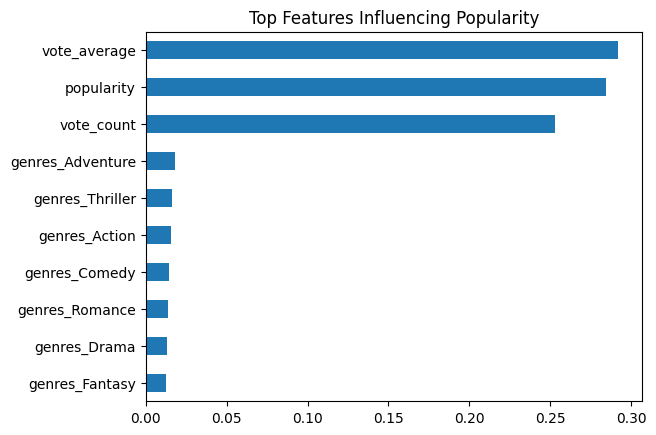

In [38]:
import matplotlib.pyplot as plt

importance.sort_values().tail(10).plot(kind='barh')
plt.title("Top Features Influencing Popularity")
plt.show()